In [1]:
import pandas as pd
import numpy as np

In [4]:
historical = pd.read_csv("historical_data.csv")
fear_greed = pd.read_csv("fear_greed_index.csv")

In [5]:
print(historical.shape)
print(fear_greed.shape)

(211224, 16)
(2644, 4)


In [7]:
print("Historical Columns:")
print(historical.columns)

print("\nFear & Greed Columns:")
print(fear_greed.columns)

Historical Columns:
Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp'],
      dtype='object')

Fear & Greed Columns:
Index(['timestamp', 'value', 'classification', 'date'], dtype='object')


In [8]:
print("Missing values in Historical Data:")
print(historical.isnull().sum())

print("\nMissing values in Fear & Greed Data:")
print(fear_greed.isnull().sum())

Missing values in Historical Data:
Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64

Missing values in Fear & Greed Data:
timestamp         0
value             0
classification    0
date              0
dtype: int64


In [9]:
#duplicate rows in the data
print(historical.duplicated().sum())
print(fear_greed.duplicated().sum())

0
0


In [11]:
historical['Timestamp'] = pd.to_datetime(historical['Timestamp'], unit='ms')
fear_greed['Timestamp'] = pd.to_datetime(historical['Timestamp'], unit='s')

In [14]:
historical['date'] = historical['Timestamp'].dt.date
fear_greed['date'] = pd.to_datetime(fear_greed['date']).dt.date

In [15]:
#align datasets by date
merged_data = pd.merge(
    historical,
    fear_greed[['date','value','classification']],
    on='date',
    how='left'
)

merged_data.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,date,value,classification
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,2024-10-27 03:33:20,2024-10-27,74.0,Greed
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,2024-10-27 03:33:20,2024-10-27,74.0,Greed
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,2024-10-27 03:33:20,2024-10-27,74.0,Greed
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,2024-10-27 03:33:20,2024-10-27,74.0,Greed
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,2024-10-27 03:33:20,2024-10-27,74.0,Greed


In [18]:
#daily PnL per Trader
daily_pnl = historical.groupby(['Account','date'])['Closed PnL'].sum().reset_index()
daily_pnl.head()

,Account,date,Closed PnL
0,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-10-27,-3.275059e+05
1,0x083384f897ee0f19899168e3b1bec365f52a9012,2025-02-19,1.927736e+06
2,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,2024-10-27,2.060745e+04
3,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,2025-02-19,1.709873e+04
4,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,2025-06-15,1.017915e+04


In [19]:
#win rate = profitable trades/total trades
historical['win'] = historical['Closed PnL'] > 0

win_rate = historical.groupby('Account')['win'].mean().reset_index()

win_rate.rename(columns={'win':'win_rate'}, inplace=True)

win_rate.head()

,Account,win_rate
0,0x083384f897ee0f19899168e3b1bec365f52a9012,0.359612
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,0.442720
2,0x271b280974205ca63b716753467d5a371de622ab,0.301917
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,0.438585
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,0.519914


In [20]:
#avg trade size
avg_trade_size = historical.groupby('Account')['Size USD'].mean().reset_index()

avg_trade_size.rename(columns={'Size USD':'avg_trade_size_usd'}, inplace=True)

avg_trade_size.head()

,Account,avg_trade_size_usd
0,0x083384f897ee0f19899168e3b1bec365f52a9012,16159.576734
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,1653.226327
2,0x271b280974205ca63b716753467d5a371de622ab,8893.000898
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,507.626933
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,3138.894782


In [21]:
#leverage distribution 
historical['leverage'] = historical['Size USD'] / historical['Start Position']

leverage_distribution = historical['leverage'].describe()

print(leverage_distribution)

count    2.112240e+05
mean              inf
std               NaN
min     -1.045050e+10
25%     -2.710120e-02
50%      1.353705e-02
75%      6.390805e-01
max               inf
Name: leverage, dtype: float64


C:\Users\Lakshmi Singh\AppData\Local\Programs\Python\Python313\Lib\site-packages\pandas\core\nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


In [22]:
#number og trades per day
trades_per_day = historical.groupby('date').size().reset_index(name='num_trades')

trades_per_day.head()

,date,num_trades
0,2023-03-28,3
1,2023-11-14,1045
2,2024-03-09,6962
3,2024-07-03,7141
4,2024-10-27,35241


In [23]:
#long/short ratio
long_short = historical['Side'].value_counts()

print(long_short)

long_short_ratio = long_short['BUY'] / long_short['SELL']

print("Long/Short Ratio:", long_short_ratio)

Side
SELL    108528
BUY     102696
Name: count, dtype: int64
Long/Short Ratio: 0.9462627156125608


In [24]:
#dataset ready for analysis 
print("Final merged dataset shape:", merged_data.shape)

merged_data.head()

Final merged dataset shape: (211224, 19)


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,date,value,classification
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,2024-10-27 03:33:20,2024-10-27,74.0,Greed
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,2024-10-27 03:33:20,2024-10-27,74.0,Greed
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,2024-10-27 03:33:20,2024-10-27,74.0,Greed
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,2024-10-27 03:33:20,2024-10-27,74.0,Greed
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,2024-10-27 03:33:20,2024-10-27,74.0,Greed


In [25]:
merged_data['win'] = merged_data['Closed PnL'] > 0

In [26]:
performance_sentiment = merged_data.groupby('classification').agg(
    avg_pnl=('Closed PnL','mean'),
    total_pnl=('Closed PnL','sum'),
    win_rate=('win','mean'),
    trades=('Closed PnL','count')
).reset_index()

performance_sentiment

,classification,avg_pnl,total_pnl,win_rate,trades
0,Extreme Greed,25.418772,1.769655e+05,0.490089,6962
1,Fear,50.047622,6.699925e+06,0.415146,133871
2,Greed,87.894859,3.189617e+06,0.446471,36289
3,Neutral,22.229713,1.587424e+05,0.317182,7141


In [27]:
drawdown_proxy = merged_data[merged_data['Closed PnL'] < 0].groupby('classification')['Closed PnL'].mean()

drawdown_proxy

classification
Extreme Greed    -86.703571
Fear            -150.445182
Greed           -178.268548
Neutral         -301.002712
Name: Closed PnL, dtype: float64

In [28]:
trades_per_day = merged_data.groupby(['date','classification']).size().reset_index(name='trades')

trades_per_day.groupby('classification')['trades'].mean()

classification
Extreme Greed      6962.000000
Fear             133871.000000
Greed             12096.333333
Neutral            7141.000000
Name: trades, dtype: float64

In [29]:
avg_position_size = merged_data.groupby('classification')['Size USD'].mean()

avg_position_size

classification
Extreme Greed    5660.265764
Fear             5259.977837
Greed            3182.883845
Neutral          3058.848110
Name: Size USD, dtype: float64

In [30]:
long_short_bias = pd.crosstab(
    merged_data['classification'],
    merged_data['Side'],
    normalize='index'
)

long_short_bias

Side,BUY,SELL
classification,,
Extreme Greed,0.484200,0.515800
Fear,0.493617,0.506383
Greed,0.424950,0.575050
Neutral,0.490828,0.509172


In [31]:
#trader segmentation 
#segment 1: High vs low leverage traders
merged_data['leverage'] = merged_data['Size USD'] / merged_data['Start Position']

In [32]:
merged_data['leverage_group'] = pd.qcut(
    merged_data['leverage'],
    q=2,
    labels=['Low Leverage','High Leverage']
)

C:\Users\Lakshmi Singh\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_function_base_impl.py:4671: RuntimeWarning: invalid value encountered in subtract
  diff_b_a = subtract(b, a)


In [33]:
leverage_performance = merged_data.groupby('leverage_group')['Closed PnL'].mean()

leverage_performance

C:\Users\Lakshmi Singh\AppData\Local\Temp\ipykernel_27852\1639422774.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  leverage_performance = merged_data.groupby('leverage_group')['Closed PnL'].mean()


leverage_group
Low Leverage     38.516889
High Leverage    58.981112
Name: Closed PnL, dtype: float64

In [34]:
#segment 2: frequent vs Infrequent Traders 
trader_activity = merged_data.groupby('Account').size().reset_index(name='trade_count')

In [35]:
trader_activity['activity_group'] = pd.qcut(
    trader_activity['trade_count'],
    q=2,
    labels=['Infrequent','Frequent']
)

In [36]:
merged_data = merged_data.merge(trader_activity[['Account','activity_group']], on='Account')

In [37]:
activity_performance = merged_data.groupby('activity_group')['Closed PnL'].mean()

activity_performance

C:\Users\Lakshmi Singh\AppData\Local\Temp\ipykernel_27852\165209063.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  activity_performance = merged_data.groupby('activity_group')['Closed PnL'].mean()


activity_group
Infrequent    96.943024
Frequent      42.493421
Name: Closed PnL, dtype: float64

In [38]:
#consistent vs inconsistent traders 
trader_winrate = merged_data.groupby('Account')['win'].mean().reset_index()

In [39]:
trader_winrate['consistency'] = pd.qcut(
    trader_winrate['win'],
    q=2,
    labels=['Inconsistent','Consistent']
)

In [40]:
merged_data = merged_data.merge(trader_winrate[['Account','consistency']], on='Account')

In [41]:
consistency_perf = merged_data.groupby('consistency')['Closed PnL'].mean()

consistency_perf

C:\Users\Lakshmi Singh\AppData\Local\Temp\ipykernel_27852\351822001.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  consistency_perf = merged_data.groupby('consistency')['Closed PnL'].mean()


consistency
Inconsistent    62.488537
Consistent      38.783637
Name: Closed PnL, dtype: float64

In [42]:
import matplotlib.pyplot as plt
import seaborn as sns

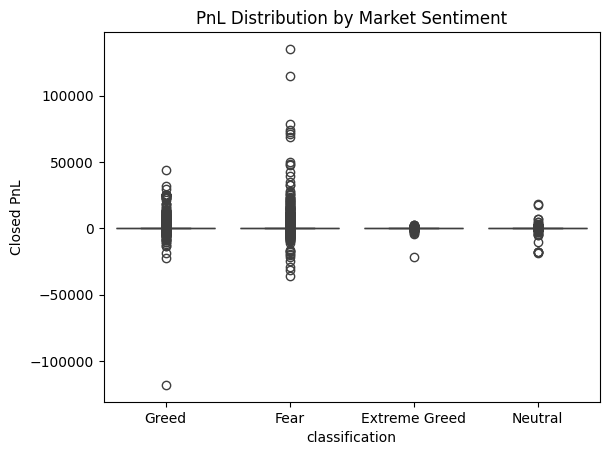

In [43]:
sns.boxplot(x='classification', y='Closed PnL', data=merged_data)
plt.title("PnL Distribution by Market Sentiment")
plt.show()

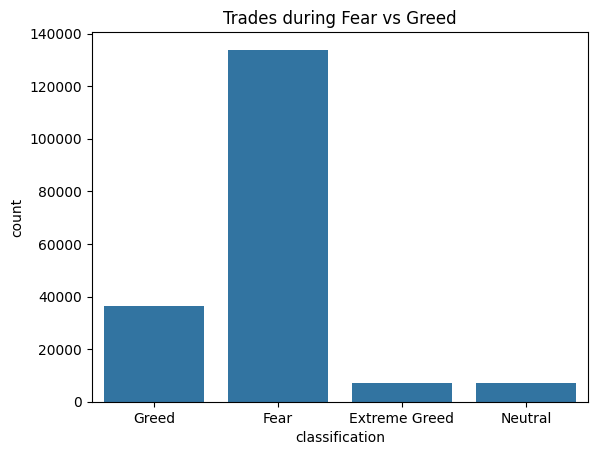

In [44]:
sns.countplot(x='classification', data=merged_data)
plt.title("Trades during Fear vs Greed")
plt.show()

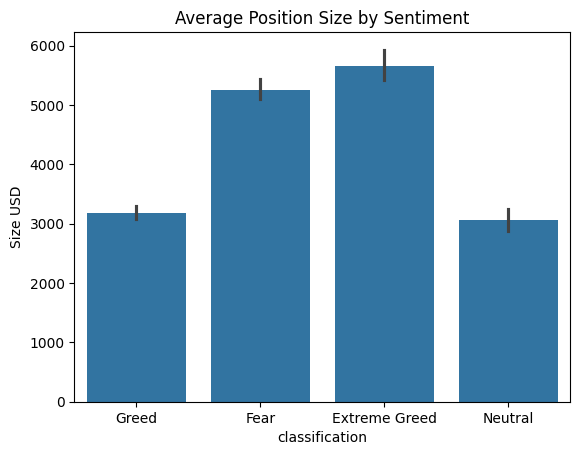

In [45]:
sns.barplot(x='classification', y='Size USD', data=merged_data)
plt.title("Average Position Size by Sentiment")
plt.show()